## LAB : 05


- NAME : MUHAMMAD FASIH
- ROLL NO : 24F-AI-016

## TASK 01 : LOAD DATASET

- Load a dataset for classification (e.g., Titanic, Breast Cancer dataset). 

In [3]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer dataset
cancer = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["target"] = cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## TASK : 02 DATA PREPROCESSING
-  Apply data preprocessing (handle missing values, encode categorical data).

In [5]:
from sklearn.impute import SimpleImputer

# Separate features and target
X = df.drop(columns="target").copy()
y = df["target"].copy()

# Identify column types
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns

# Handle missing numerical values
if len(numeric_cols) > 0:
    numeric_imputer = SimpleImputer(strategy="median")
    X[numeric_cols] = numeric_imputer.fit_transform(X[numeric_cols])

# Handle and encode categorical values
if len(categorical_cols) > 0:
    for column in categorical_cols:
        X[column] = X[column].fillna(X[column].mode()[0])
    X = pd.get_dummies(X, columns=categorical_cols, dtype=int)

# Combine preprocessed features with target
df_preprocessed = X.copy()
df_preprocessed["target"] = y

print("Missing values after preprocessing:", df_preprocessed.isnull().sum().sum())
df_preprocessed.head()

Missing values after preprocessing: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


##  task 03 :TRAINING AND TESTING DATASET
- Split the dataset into training and testing sets.


In [6]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training features: (455, 30)
Testing features: (114, 30)
Training targets: (455,)
Testing targets: (114,)


## TASK 04 : BUILD RANDOM FOREST CLASSIFIER
- Train a Random Forest Classifier on the training data. 

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the Random Forest classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


## TASK 05 : PREDICTION ON TEST DATA
 - Make predictions on the test set. 

In [8]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

print("Predictions on test data:")
print(y_pred)

Predictions on test data:
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


## TASK 06 : ACCURACY,PRECISION,RECALL,PRECISION _SCORE
- Evaluate performance using accuracy, precision, recall, and F1-score. 

In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy of the model on test data:", accuracy)  

Accuracy of the model on test data: 0.956140350877193


In [10]:
from sklearn.metrics import precision_score

precision = precision_score(y_test,y_pred)
print("Precision of the model on test data:", precision)

Precision of the model on test data: 0.958904109589041


In [11]:
from sklearn.metrics import recall_score

recall = recall_score(y_test,y_pred)
print("Recall of the model on test data:",recall_score)

Recall of the model on test data: <function recall_score at 0x0000023DBBEEAD40>


In [12]:
from sklearn.metrics import f1_score
score = f1_score(y_test,y_pred)
print("f1 score of the model on test dara:",score)

f1 score of the model on test dara: 0.9655172413793104


## task 07 : VISUALIZATION
- Visualize the Confusion Matrix 

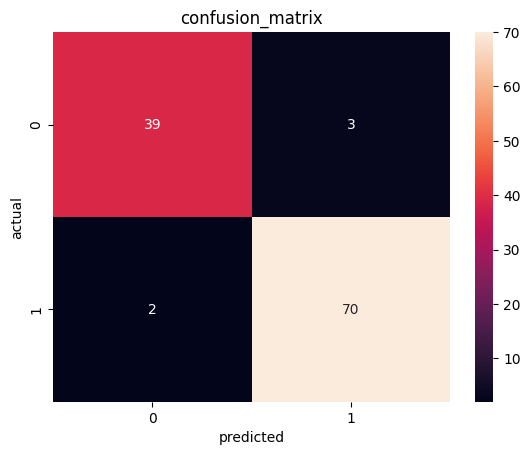

In [13]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
from matplotlib import pyplot as plt

cm = confusion_matrix(y_test,y_pred)

heatmap = sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion_matrix")

plt.show()

## TASK 08 : COMPARIG WITH DECISION TREE
 - Compare with a Single Decision Tree 


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Decision Tree Model
dt = DecisionTreeClassifier(random_state=42)

# train

dt.fit(X_train, y_train)

# predict

y_pred_dt = dt.predict(X_test)

# accurcay

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy of Decision Tree model on test data:", accuracy_dt)



Accuracy of Decision Tree model on test data: 0.9122807017543859
